# Financial Tweet Sentiment Analysis — Data Preprocessing

Ce notebook prépare les données pour les modèles de Deep Learning.

Objectifs :
- Charger les tweets financiers
- Nettoyer le texte
- Encoder les labels
- Vérifier la distribution des classes
- Diviser les données en Train / Validation / Test
- Sauvegarder les datasets préprocessés

**Imports & Configuration**

In [2]:
import os, json, random
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
from transformers import AutoTokenizer

# ── Seeds reproductibilité ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Chemins ─────────────────────────────────────────────────────────────────
RAW_FILE   = 'data/processed/stock_tweets_cleaned_capped_sentiment_responses_minimal.csv'
OUT_DIR    = Path('data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR    = Path('results')
RES_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparamètres ─────────────────────────────────────────────────────────
MAX_LENGTH   = 128        # justifié : tweets → ~60 tokens en moyenne
TOKENIZER_ID = 'ProsusAI/finbert'   # utilisé pour les 3 modèles transformers ≤ 280 chars
SPLIT_RATIOS = (0.70, 0.15, 0.15)   # train / val / test

print('OUT_DIR:', OUT_DIR)

d:\M2_MoSEF\NLP_Project\NLP_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OUT_DIR: data\processed


**Chargement des données labellisées**

In [3]:
df = pd.read_csv(RAW_FILE, encoding='utf-8-sig')

# Garder les colonnes utiles
KEEP = ['Tweet_clean', 'Tweet_original', 'Stock Name', 'Date', 'sentiment', 'sentiment_score']
df = df[[c for c in KEEP if c in df.columns]].copy()


# Convertion sentiment_score (+1/0/-1) en label entier (0/1/2)
# Convention : 0=négatif, 1=neutre, 2=positif
SCORE_TO_LABEL = {-1: 0, 0: 1, 1: 2}
LABEL_TO_NAME  = {0: 'négatif', 1: 'neutre', 2: 'positif'}
df['label'] = df['sentiment_score'].map(SCORE_TO_LABEL).astype(int)

df = df.reset_index(drop=False).rename(columns={'index': 'original_index'})
print(f'Dataset final : {len(df)} exemples')
df.head(3)

Dataset final : 42252 exemples


,original_index,Tweet_clean,Tweet_original,Stock Name,Date,sentiment,sentiment_score,label
0,0,"Sell AMOUNT_41,000 worth of TICKER_AAPL for 1,...","Sell $41,000 worth of $AAPL for 1,000 more sha...",AAPL,2021-11-02 00:27:27+00:00,neutral,0,1
1,1,"TICKER_AAPL CFO, Luca Maestri, filed Form 144 ...","$AAPL CFO, Luca Maestri, filed Form 144 paperw...",AAPL,2022-08-18 20:34:48+00:00,neutral,0,1
2,2,TICKER_AAPL they re gonna say the news is fake...,$AAPL they’re gonna say the news is fake and t...,AAPL,2022-09-28 13:09:01+00:00,negative,-1,0


**Distribution des classes**

Distribution des classes :
  négatif (0) : 7980 (18.9%)
  neutre (1) : 18468 (43.7%)
  positif (2) : 15804 (37.4%)


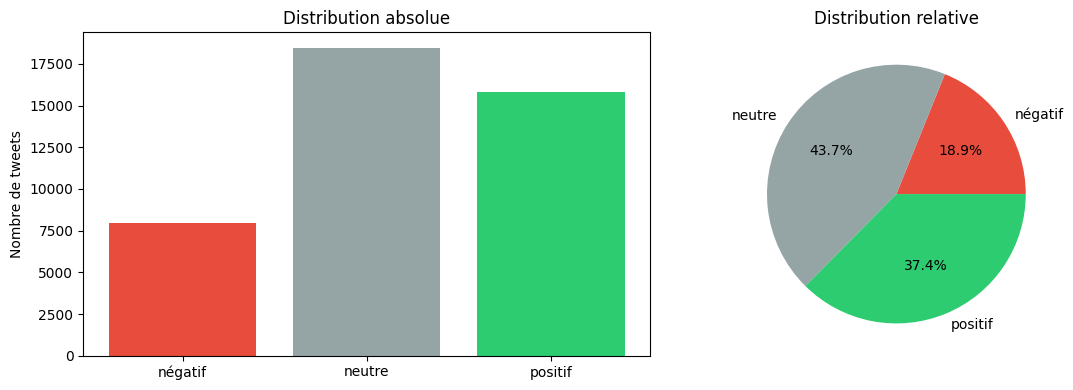


Ratio max/min : 2.31
Déséquilibre modéré : class_weight + surveiller F1 par classe


In [4]:
counts = df['label'].value_counts().sort_index()
print('Distribution des classes :')
for lbl, cnt in counts.items():
    print(f'  {LABEL_TO_NAME[lbl]} ({lbl}) : {cnt} ({100*cnt/len(df):.1f}%)')
    

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([LABEL_TO_NAME[i] for i in counts.index], counts.values,
            color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Distribution absolue')
axes[0].set_ylabel('Nombre de tweets')

axes[1].pie(counts.values, labels=[LABEL_TO_NAME[i] for i in counts.index],
            autopct='%1.1f%%', colors=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('Distribution relative')
plt.tight_layout()
plt.savefig(RES_DIR / 'class_distribution.png', dpi=150)
plt.show()

# ── Calcul du ratio de déséquilibre ─────────────────────────────────────────
imbalance_ratio = counts.max() / counts.min()
print(f'\nRatio max/min : {imbalance_ratio:.2f}')

if imbalance_ratio < 2.0:
    strategy = 'class_weight'
    print('Déséquilibre léger : stratégie class_weight (sklearn + PyTorch)')
elif imbalance_ratio < 5.0:
    strategy = 'class_weight'
    print('Déséquilibre modéré : class_weight + surveiller F1 par classe')
else:
    strategy = 'focal_loss'
    print('Fort déséquilibre : Focal Loss recommandée')


In [5]:
# ── Calcul des poids de pénalisation selon la classe et sa répartition ─────────────────────────────────────────────────
labels_array = df['label'].values
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=labels_array
)
class_weights_dict = {int(i): float(w) for i, w in enumerate(class_weights_array)}
print('\nClass weights :', class_weights_dict)

with open(RES_DIR / 'class_weights.json', 'w') as f:
    json.dump({
        'weights': class_weights_dict,
        'strategy': strategy,
        'imbalance_ratio': float(imbalance_ratio),
        'label_mapping': SCORE_TO_LABEL
    }, f, indent=2)
print('Sauvegardé : results/class_weights.json')


Class weights : {0: 1.7649122807017543, 1: 0.7626164175871778, 2: 0.8911667932169071}
Sauvegardé : results/class_weights.json


**Split Train / Validation / Test (stratifié)**

In [6]:
# ── Utilisation de la stratification ──────────────────────────────────────────────────────
# un split aléatoire simple pourrait créer val/test avec 0 exemples de la classe
# minoritaire. Le split stratifié garantit les mêmes proportions dans chaque split.

TRAIN_RATIO = SPLIT_RATIOS[0]  # 0.70
VAL_RATIO   = SPLIT_RATIOS[1]  # 0.15
TEST_RATIO  = SPLIT_RATIOS[2]  # 0.15

# Étape 1 : train vs (val+test)
df_train, df_temp = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=SEED
)

# Étape 2 : val vs test (50/50 du temp)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5,
    stratify=df_temp['label'], random_state=SEED
)

print(f'Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}')

# Vérifier la distribution dans chaque split
for name, subset in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = subset['label'].value_counts(normalize=True).sort_index()
    print(f'{name} → ' + ' | '.join(f'{LABEL_TO_NAME[i]}: {v:.1%}' for i, v in dist.items()))



Train : 29576 | Val : 6338 | Test : 6338
Train → négatif: 18.9% | neutre: 43.7% | positif: 37.4%
Val → négatif: 18.9% | neutre: 43.7% | positif: 37.4%
Test → négatif: 18.9% | neutre: 43.7% | positif: 37.4%


**Sauvegarde des CSV**

In [7]:
COLS_OUT = ['original_index', 'Tweet_clean', 'label', 'Stock Name', 'Date']
COLS_OUT = [c for c in COLS_OUT if c in df_train.columns]

df_train[COLS_OUT].to_csv(OUT_DIR / 'train.csv', index=False)
df_val[COLS_OUT].to_csv(OUT_DIR  / 'val.csv',   index=False)
df_test[COLS_OUT].to_csv(OUT_DIR / 'test.csv',  index=False)

print('Sauvegardés : train.csv / val.csv / test.csv')

Sauvegardés : train.csv / val.csv / test.csv


**Tokenisation & Sauvegarde des encodings (.pt) pour eviter de recalculer**

In [8]:
# ── Pourquoi max_length=128 ? ─────────────────────────────────────────────────
# Les tweets font max 280 caractères ≈ 50-70 tokens en moyenne.
# max_length=128 couvre >99% des tweets avec un padding raisonnable.
# max_length=512 (défaut BERT) multiplierait par 4 la mémoire GPU sans gain.

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

# ── Ajouter les tokens spéciaux TICKER et AMOUNT ─────────────────────────────
# Ces tokens issus du preprocessing doivent être reconnus par le tokenizer.
special_tokens = [f'TICKER_{s}' for s in [
    'AAPL','MSFT','GOOGL','AMZN','TSLA','META','NVDA','BRK','JPM',
    'JNJ','V','PG','UNH','HD','MA','PYPL','BAC','DIS','ADBE','NFLX',
    'CMCSA','XOM','VZ','INTC','T','CSCO','PFE'
]] + ['AMOUNT_']

tokenizer.add_tokens(special_tokens, special_tokens=False)

def tokenize_split(texts, tokenizer, max_length=128):
    return tokenizer(
        list(texts),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
        return_attention_mask=True
    )

for split_name, subset in [('train', df_train), ('val', df_val), ('test', df_test)]:
    enc = tokenize_split(subset['Tweet_clean'], tokenizer)
    out = {
        'input_ids':      enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels':         torch.tensor(subset['label'].values, dtype=torch.long),
    }
    torch.save(out, OUT_DIR / f'{split_name}_encodings.pt')
    print(f' {split_name}_encodings.pt — input_ids shape: {out["input_ids"].shape}')
    #.pt car consommable facilement avec pytorch.

# Vérification dimensions
enc_check = torch.load(OUT_DIR / 'train_encodings.pt')
N, L = enc_check['input_ids'].shape
assert L == MAX_LENGTH, f'Longueur attendue {MAX_LENGTH}, obtenu {L}'
print(f'\n Dimensions encodings : {N} × {L}')

d:\M2_MoSEF\NLP_Project\NLP_Project\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Juan David Alonso\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


 train_encodings.pt — input_ids shape: torch.Size([29576, 128])
 val_encodings.pt — input_ids shape: torch.Size([6338, 128])
 test_encodings.pt — input_ids shape: torch.Size([6338, 128])

 Dimensions encodings : 29576 × 128


**Checklist finale**

In [9]:
print('=' * 60)
print('CHECKLIST FINALE')
print('=' * 60)

checks = []

# 1. Aucun NaN dans les splits
for fname in ['train.csv', 'val.csv', 'test.csv']:
    tmp = pd.read_csv(OUT_DIR / fname)
    nan_count = tmp.isnull().sum().sum()
    checks.append((f'Aucun NaN — {fname}', nan_count == 0))

# 2. Distribution cohérente
train_dist = pd.read_csv(OUT_DIR / 'train.csv')['label'].value_counts(normalize=True)
test_dist  = pd.read_csv(OUT_DIR / 'test.csv')['label'].value_counts(normalize=True)
max_drift  = (train_dist - test_dist).abs().max()
checks.append(('Distribution train/test cohérente (drift < 3%)', max_drift < 0.03))

# 3. Pas de data leakage
t1 = set(pd.read_csv(OUT_DIR / 'train.csv')['original_index'])
t2 = set(pd.read_csv(OUT_DIR / 'val.csv')['original_index'])
t3 = set(pd.read_csv(OUT_DIR / 'test.csv')['original_index'])
checks.append(('Aucun data leakage', len(t1&t2)==0 and len(t1&t3)==0 and len(t2&t3)==0))

# 5. Encodings dimensions
enc = torch.load(OUT_DIR / 'train_encodings.pt')
checks.append((f'Encodings shape N×{MAX_LENGTH}', enc["input_ids"].shape[1] == MAX_LENGTH))

# 6. class_weights.json
checks.append(('class_weights.json sauvegardé', (RES_DIR / 'class_weights.json').exists()))

for label, ok in checks:
    status = 'OK' if ok else 'NOT OK'
    print(f'  {status} {label}')

all_ok = all(ok for _, ok in checks)
print('\n' + ('PREPROCESSING TERMINÉ — Prêt pour la modélisation' if all_ok else '❌ ERREURS DÉTECTÉES — Corriger avant de continuer'))

CHECKLIST FINALE
  OK Aucun NaN — train.csv
  OK Aucun NaN — val.csv
  OK Aucun NaN — test.csv
  OK Distribution train/test cohérente (drift < 3%)
  OK Aucun data leakage
  OK Encodings shape N×128
  OK class_weights.json sauvegardé

PREPROCESSING TERMINÉ — Prêt pour la modélisation
